# Adjoints and Backprop, Part 4: Gradient descent is a time stepper

*In Parts 1–3 we kept running into time steppers, from the ball's flight in Part 1 to ResNets in Part 3. In this part we look at the optimizer the same way, and use it to introduce an idea involved in my own research, **nonlinear splitting**.*

*In that research we applied these ideas to optimization problems constrained by neutron transport equations, not to machine learning, so nothing here is a new ML method. Instead, I'll demonstrate the ideas on the small network from Part 2.*

Back in Part 1 we noted that the adjoint's job is to deliver a derivative, and that what we do with that derivative is a separate choice. Parts 1–3 were mostly about getting the derivative, and then we'd usually just hand it to a pre-built optimizer (BFGS, Adam). Here we'll focus on what to do with it.

**In this part:**

1. Gradient descent as forward Euler
2. Nonlinear splitting
3. Splitting a network's gradient
4. Splitting the constraint
5. Recap

The cell below sets the plot style, carries over the network from Part 2, and adds two small helpers that flatten its weights and biases into a single vector $\theta$ and back.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Plot style (same as Parts 1-3).
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID, SURFACE = "#1d1d1b", "#52514e", "#e7e6e2", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": INK2, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "text.color": INK, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 12, "axes.titlesize": 12.5, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "lines.linewidth": 2, "legend.frameon": False, "legend.fontsize": 11,
    "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, AQUA]),
})

# ======== Carried over from Part 2: the data and the network ========
rng = np.random.default_rng(1)
m = 80
x_data = np.sort(rng.uniform(-1, 1, m))
y_data = np.sin(4 * x_data) + 0.1 * rng.normal(size=m)
X, Y = x_data[None, :], y_data[None, :]
sizes = [1, 32, 32, 1]

def init_params(sizes, rng):
    return [(rng.normal(size=(n_out, n_in)) / np.sqrt(n_in), np.zeros((n_out, 1)))
            for n_in, n_out in zip(sizes[:-1], sizes[1:])]

def forward(params, X):
    a, acts = X, [X]
    for k, (W, b) in enumerate(params):
        z = W @ a + b
        a = z if k == len(params) - 1 else np.tanh(z)
        acts.append(a)
    return acts

params0 = init_params(sizes, rng)
noise_floor = 0.5 * np.mean((np.sin(4 * x_data) - y_data)**2)    # loss of the true curve, as in Part 2

# ======== New: flatten all weights and biases into one vector theta, and back ========
shapes = [(W.shape, b.shape) for W, b in params0]

def pack(params):
    return np.concatenate([np.concatenate([W.ravel(), b.ravel()]) for W, b in params])

def unpack(theta):
    params, i = [], 0
    for sW, sb in shapes:
        nW, nb = int(np.prod(sW)), int(np.prod(sb))
        params.append((theta[i:i + nW].reshape(sW), theta[i + nW:i + nW + nb].reshape(sb)))
        i += nW + nb
    return params

def loss(theta):
    return 0.5 * np.mean((forward(unpack(theta), X)[-1] - Y)**2)

theta0 = pack(params0)

## 1. Gradient descent as forward Euler

Training moves the parameters $\theta$ so as to make the loss $\mathcal{L}(\theta)$ smaller. If we imagine doing this continuously we get the ODE
$$ \dot\theta(t) = -\nabla\mathcal{L}\big(\theta(t)\big), $$
(often called the **gradient flow**). Along it the loss can only decrease, since $\tfrac{d}{dt}\mathcal{L} = -|\nabla\mathcal{L}|^2$.

If we solve it with forward Euler, using the step size $\gamma$ (the learning rate) as the time step, we get gradient descent:
$$ \theta_{k+1} = \theta_k - \gamma\,\nabla\mathcal{L}(\theta_k). $$
This is the same kind of step as Part 1's simulator, so it comes with forward Euler's main weakness: picking $\gamma$ is hard to do well. Take the simplest possible loss, $\mathcal{L} = \tfrac{\lambda}{2}\theta^2$. Each step multiplies $\theta$ by $1 - \gamma\lambda$, so gradient descent converges if $\gamma < 2/\lambda$ and blows up if $\gamma$ is any larger. For a general loss, $\lambda$ is replaced by the largest curvature (the largest eigenvalue of the Hessian), so saying "the learning rate is too high" is equivalent to saying "the time step is too large for the steepest direction in the problem." On top of that, this one direction limits the step size for every other direction too, so progress along the flatter directions can be very slow.

The standard fix for this is to use an **implicit** step, i.e. backward Euler, which evaluates the gradient at the *new* point:
$$ \theta_{k+1} = \theta_k - \gamma\,\nabla\mathcal{L}(\theta_{k+1}). $$
On the quadratic, each step now divides $\theta$ by $1 + \gamma\lambda$, which shrinks it for any step size. (In optimization this is known as the *proximal point method*.) The downside is that $\theta_{k+1}$ now appears on both sides, so every step requires solving a nonlinear equation in all of the network's parameters, which is potentially just as hard as training the network in the first place.

## 2. Nonlinear splitting

Time integration also offers something in between the explicit step (cheap, but limited) and the implicit one (stable, but expensive), which is to only be implicit in the parts of the problem where that's cheap.

To begin, we write the gradient as a function of *two* points, an old one and a new one, in any way that agrees with the true gradient when the two points coincide:
$$ \widetilde\nabla\mathcal{L}(\theta_{\text{old}}, \theta_{\text{new}}), \qquad \widetilde\nabla\mathcal{L}(\theta, \theta) = \nabla\mathcal{L}(\theta). $$
This is called a **nonlinear splitting** of the gradient, and the optimizer step is explicit in the first slot and implicit in the second:
$$ \theta_{k+1} = \theta_k - \gamma\,\widetilde\nabla\mathcal{L}(\theta_k, \theta_{k+1}). $$
Putting everything in the first slot gives back gradient descent, and putting everything in the second gives the implicit step, so the interesting choices are the splittings in between. As a simple example, if a formula contains $q(y) = y^2$ we could write it as $\tilde q(y_{\text{old}}, y_{\text{new}}) = y_{\text{old}}\,y_{\text{new}}$ instead. This is still $y^2$ when old and new agree, but solving for $y_{\text{new}}$ is now a linear problem rather than a quadratic one.

### Splitting a least-squares loss

Our network's loss is a sum of squares. If we collect the scaled errors into a residual vector $r(\theta)$, with entries $r_i = (\hat y_i - y_i)/\sqrt{m}$, then $\mathcal{L} = \tfrac12|r|^2$ and its gradient is
$$ \nabla\mathcal{L}(\theta) = J(\theta)^\top r(\theta), $$
where $J = \partial r/\partial\theta$ is the Jacobian, with one row per data point. A natural split is to take the Jacobian at the old point and the residual at the new one:
$$ \widetilde\nabla\mathcal{L}(\theta_{\text{old}}, \theta_{\text{new}}) = J(\theta_{\text{old}})^\top r(\theta_{\text{new}}). $$
Freezing the Jacobian makes the implicit step easier, but unlike the $y^2$ example it doesn't make it linear, since the residual is still a nonlinear function of $\theta_{\text{new}}$. Taking the step exactly would mean solving
$$ \theta_{k+1} + \gamma\,J_k^\top r(\theta_{k+1}) = \theta_k $$
for $\theta_{k+1}$, where $J_k = J(\theta_k)$. Rather than solving this exactly, we approximate it with a single iteration of Newton's method, starting from $\theta_k$. The Jacobian of the left-hand side is $I + \gamma J_k^\top J(\theta_{k+1})$, which at $\theta_k$ is $I + \gamma J_k^\top J_k$, so this one Newton iteration is just one linear solve:
$$ \boxed{\;(I + \gamma\,J_k^\top J_k)\,\Delta\theta = -\gamma\,J_k^\top r_k, \qquad \theta_{k+1} = \theta_k + \Delta\theta\;} $$

When $\gamma$ is small the $\gamma J^\top J$ term is negligible, and the step is just gradient descent, $\Delta\theta \approx -\gamma J^\top r$. When $\gamma$ is large the identity is negligible instead, and the step becomes the Gauss–Newton method, $\Delta\theta \approx -(J^\top J)^{-1}J^\top r$, which uses curvature information like a second-order method would.

This particular step isn't new: it's the classical Levenberg–Marquardt method, which has long been used for least-squares fitting (small neural networks included). Seen as a splitting, though, it's one choice among many, and different splits give different optimizers.

## 3. Splitting a network's gradient

To take this step we need the whole Jacobian $J$, not just the gradient $J^\top r$. Part 2's backprop already does most of the work. Its error signal $\delta$ has one column per data point, and the parameter gradients sum over those columns, so if we skip the sum, each data point gives one row of $J$. In adjoint terms, $J$ has $m$ outputs, so it takes one backward sweep per output (the trade-off from the table at the end of Part 1), but here the 80 sweeps all run side by side as one vectorized pass.

The linear solve looks like it involves a huge matrix ($1153 \times 1153$ if you haven't changed any of the code), but since there are only $m = 80$ data points, the standard identity $(I + \gamma J^\top J)^{-1}J^\top = J^\top(I + \gamma JJ^\top)^{-1}$ turns it into an $80 \times 80$ solve instead.

In [2]:
def residual_and_jacobian(theta):
    # Part 2's backprop, keeping one row per data point instead of summing over them.
    params = unpack(theta)
    acts = forward(params, X)
    r = ((acts[-1] - Y) / np.sqrt(m)).ravel()             # residual: the loss is 0.5 |r|^2
    delta = np.ones((1, m)) / np.sqrt(m)                  # d r_i / d(output for data point i)
    rows = [None] * len(params)
    for k in reversed(range(len(params))):
        W, b = params[k]
        dW = np.einsum("oi,ni->ion", delta, acts[k])      # delta_{k+1} a_k^T, separately for each data point
        rows[k] = np.hstack([dW.reshape(m, -1), delta.T])
        if k > 0:
            delta = (1 - acts[k]**2) * (W.T @ delta)
    return r, np.hstack(rows)                             # J has shape (m, number of parameters)

def gd_step(theta, gamma):
    r, J = residual_and_jacobian(theta)                   # (Part 2's backprop gets J^T r more cheaply;
    return theta - gamma * J.T @ r                        #  we reuse J here to keep the code short)

def split_step(theta, gamma):
    r, J = residual_and_jacobian(theta)
    w = np.linalg.solve(np.eye(m) + gamma * J @ J.T, r)   # the small m x m solve
    return theta - gamma * J.T @ w                        # theta + Delta theta, from the boxed equation

def train(step, gamma, n_steps):
    theta, history = theta0.copy(), [loss(theta0)]
    for _ in range(n_steps):
        theta = step(theta, gamma)
        history.append(loss(theta))
        if not history[-1] < 1e6:                         # stop once it has clearly blown up
            break
    return np.array(history)

First, let's compare gradient descent near its step-size limit with the split step at a step size hundreds of times larger.

In [3]:
r0, J0 = residual_and_jacobian(theta0)
lam_max = np.linalg.eigvalsh(J0 @ J0.T).max()             # J^T J approximates the Hessian; same top eigenvalue
print(f"gradient descent's step-size limit, estimated at the start: 2 / lambda_max = {2 / lam_max:.2f}")

hist_gd = train(gd_step, 0.08, 1500)
hist_gd_big = train(gd_step, 0.6, 1500)
hist_split = train(split_step, 100.0, 100)

near_floor = int(np.argmax(hist_split < 1.05 * noise_floor))
print(f"gradient descent, gamma = 0.08: loss {hist_gd[-1]:.4f} after 1500 steps (noise floor {noise_floor:.4f})")
print(f"gradient descent, gamma = 0.6:  blew up after {len(hist_gd_big) - 1} steps")
print(f"split step,       gamma = 100:  within 5% of the noise floor after {near_floor} steps")

gradient descent's step-size limit, estimated at the start: 2 / lambda_max = 0.25
gradient descent, gamma = 0.08: loss 0.0061 after 1500 steps (noise floor 0.0045)
gradient descent, gamma = 0.6:  blew up after 8 steps
split step,       gamma = 100:  within 5% of the noise floor after 6 steps


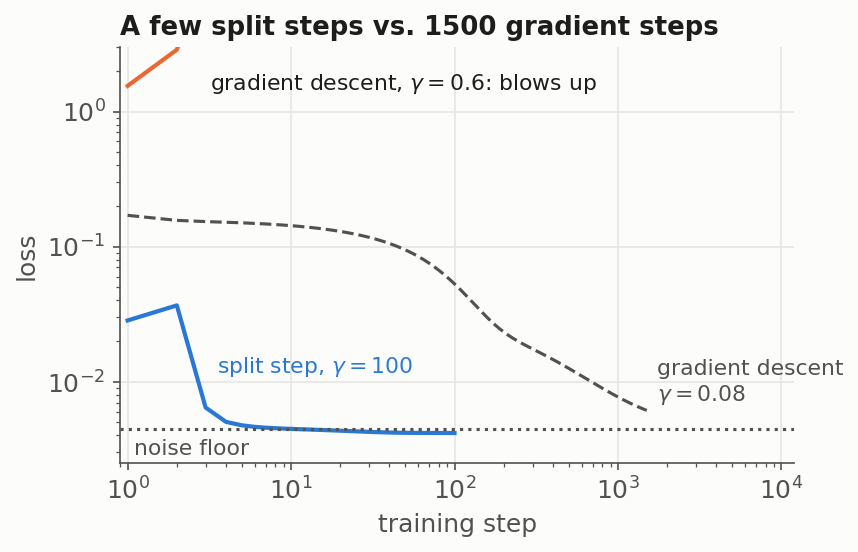

In [4]:
fig, ax = plt.subplots(figsize=(5.8, 3.6))
steps = lambda h: np.arange(1, len(h))
ax.loglog(steps(hist_gd), hist_gd[1:], color=INK2, ls="--", lw=1.5)
ax.loglog(steps(hist_gd_big), hist_gd_big[1:], color=ORANGE)
ax.loglog(steps(hist_split), hist_split[1:], color=BLUE)
ax.axhline(noise_floor, color=INK2, ls=":", lw=1.5)
ax.text(1500 * 1.15, hist_gd[-1] * 1.6, "gradient descent\n$\\gamma = 0.08$", color=INK2, fontsize=10.5, va="center")
ax.text(3.2, 1.6, "gradient descent, $\\gamma = 0.6$: blows up", color=INK, fontsize=10.5, va="center")
ax.text(3.5, 0.013, "split step, $\\gamma = 100$", color=BLUE, fontsize=10.5, va="center")
ax.text(1.1, noise_floor * 0.72, "noise floor", color=INK2, fontsize=10.5, va="center")
ax.set(xlabel="training step", ylabel="loss", xlim=(0.9, 1500 * 8), ylim=(2.5e-3, 3),
       title="A few split steps vs. 1500 gradient steps")

So (as expected) we see that gradient descent is held back by its step-size limit. At $\gamma = 0.08$ it's still short of the noise floor after 1500 steps, and at $\gamma = 0.6$ it blows up within a handful of steps. The split step, at a step size hundreds of times past that limit, reaches the noise floor in about half a dozen steps. Each split step costs considerably more than a gradient step, though, since it needs the whole Jacobian and a linear solve. To compare actual work, we can time one split step against one gradient computed with Part 2's backprop (the cheap way, without forming $J$), and count how much work each method needs to reach the noise floor.

In [10]:
import time

def gradient(theta):
    # Part 2's backprop: the gradient J^T r, without forming J
    params = unpack(theta)
    acts = forward(params, X)
    delta = (acts[-1] - Y) / m
    grads = [None] * len(params)
    for k in reversed(range(len(params))):
        W, b = params[k]
        grads[k] = (delta @ acts[k].T, delta.sum(axis=1, keepdims=True))
        if k > 0:
            delta = (1 - acts[k]**2) * (W.T @ delta)
    return pack(grads)

def time_per_call(fn, repeat=200):
    times = []
    for _ in range(repeat):
        t0 = time.perf_counter(); fn(); times.append(time.perf_counter() - t0)
    return min(times)

def steps_to_floor(update, max_steps=20000):
    # run an optimizer until the loss is within 5% of the noise floor
    theta = theta0.copy()
    for t in range(1, max_steps + 1):
        theta = update(theta, t)
        if loss(theta) < 1.05 * noise_floor:
            return t

adam = {}
def adam_update(theta, t, lr=3e-3):                       # Part 2's Adam settings
    g = gradient(theta)
    if t == 1:
        adam.update(mean=0 * g, sq=0 * g)
    adam["mean"] = 0.9 * adam["mean"] + 0.1 * g
    adam["sq"] = 0.999 * adam["sq"] + 0.001 * g**2
    return theta - lr * (adam["mean"] / (1 - 0.9**t)) / (np.sqrt(adam["sq"] / (1 - 0.999**t)) + 1e-8)

split_cost = time_per_call(lambda: split_step(theta0, 100.0)) / time_per_call(lambda: gradient(theta0))
results = [("gradient descent, gamma = 0.2", steps_to_floor(lambda th, t: th - 0.2 * gradient(th)), 1.0),
           ("Adam (as in Part 2)", steps_to_floor(adam_update), 1.0),
           ("split step, gamma = 100", steps_to_floor(lambda th, t: split_step(th, 100.0)), split_cost)]

print(f"one split step costs about {split_cost:.0f} gradient evaluations (timed on this machine)\n")
print(f"{'':32s}{'steps to noise floor':>22s}{'work, in gradients':>21s}")
for name, steps, cost in results:
    print(f"{name:32s}{steps:22d}{steps * cost:21.0f}")

one split step costs about 13 gradient evaluations (timed on this machine)

                                  steps to noise floor   work, in gradients
gradient descent, gamma = 0.2                     3692                 3692
Adam (as in Part 2)                                246                  246
split step, gamma = 100                              6                   77


Here one split step costs somewhere around 10 to 20 gradient evaluations, and most of that goes into forming the $80 \times 80$ matrix $JJ^\top$. Even so, the split step reaches the noise floor for less than about 100 gradients' worth of work, compared with about 250 for Adam and several thousand for gradient descent. (The exact numbers will depend on your machine.)

A big caveat is that this only works so nicely because the problem is "tiny" (80 data points and 1153 parameters). For a realistic industrial network and dataset, forming $J$ and solving with it isn't practical, which is why second-order-style methods for large networks rely on cheaper approximations of the curvature instead. Forming $JJ^\top$ alone takes on the order of $m^2 p$ operations for $m$ data points and $p$ parameters, so doubling the data makes each split step roughly four times as expensive.

Next we run each method for 20 steps over a whole range of step sizes.

In [1]:
def loss_after(step, gamma, n_steps=20):
    h = train(step, gamma, n_steps)
    return h[-1] if len(h) == n_steps + 1 else np.nan     # nan: it blew up

gammas = np.logspace(-2, 6, 33)
after_gd = np.array([loss_after(gd_step, g) for g in gammas])
after_split = np.array([loss_after(split_step, g) for g in gammas])

NameError: name 'np' is not defined

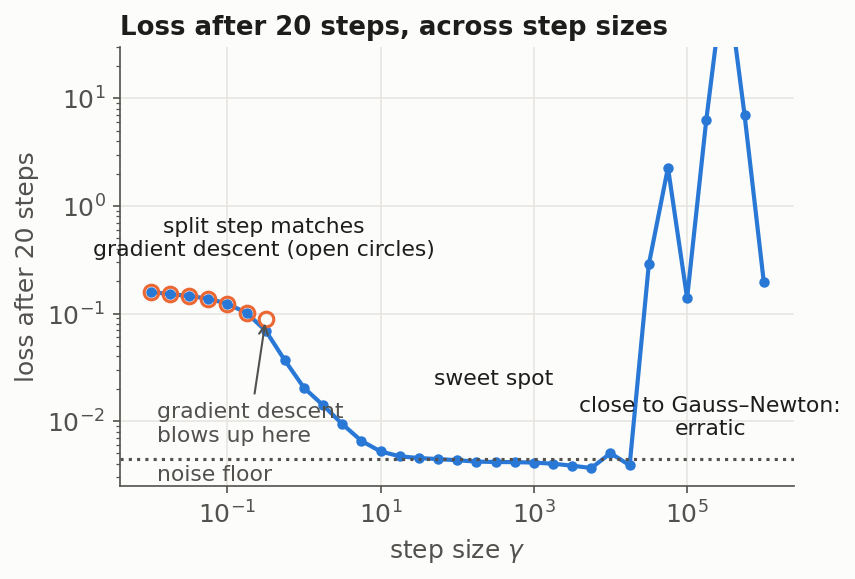

In [6]:
fig, ax = plt.subplots(figsize=(5.8, 3.8))
ok = np.isfinite(after_gd)
ax.loglog(gammas, after_split, color=BLUE, marker="o", ms=4)
ax.loglog(gammas[ok], after_gd[ok], color=ORANGE, ls="none", marker="o", ms=7, mfc="none", mew=1.5, zorder=3)
ax.axhline(noise_floor, color=INK2, ls=":", lw=1.5)
g_last = gammas[ok][-1]
ax.annotate("gradient descent\nblows up here", xy=(g_last, after_gd[ok][-1]), xytext=(0.012, 0.0095),
            color=INK2, fontsize=10.5, ha="left", va="center", arrowprops=dict(arrowstyle="->", color=INK2, lw=1))
ax.text(0.3, 0.5, "split step matches\ngradient descent (open circles)", color=INK, fontsize=10.5, ha="center", va="center")
ax.text(300, 0.025, "sweet spot", color=INK, fontsize=10.5, ha="center", va="center")
ax.text(2e5, 0.011, "close to Gauss–Newton:\nerratic", color=INK, fontsize=10.5, ha="center", va="center")
ax.text(1.2e-2, noise_floor * 0.72, "noise floor", color=INK2, fontsize=10.5, va="center")
ax.set(xlabel="step size $\\gamma$", ylabel="loss after 20 steps", ylim=(2.5e-3, 30),
       title="Loss after 20 steps, across step sizes")

For small $\gamma$, the split step and gradient descent (open circles) lie on top of each other, as the boxed formula predicts. In the middle, over a range of step sizes several hundred times wide, 20 split steps are enough to reach the noise floor. (Points just below the dotted line mean the network has started fitting the noise, which a fast optimizer gets to quickly.) For large $\gamma$, the step turns into Gauss–Newton and becomes erratic. With 1153 parameters and only 80 data points, Gauss–Newton can always make the *linearized* residual exactly zero, and it will take whatever step that requires, even one that lands far outside the region where the linearization is any good. For moderate $\gamma$ the identity term in $I + \gamma J^\top J$ limits how far the step can go, but at huge $\gamma$ it's negligible.

This erratic behavior at large $\gamma$ comes from the shortcut we took, namely taking a single Newton step instead of solving for $\theta_{k+1}$ exactly. The convergence theory for exact split steps (including when they converge for any step size) is worked out in the paper listed at the end.

## 4. Splitting the constraint

Everything so far splits the *gradient*, i.e. it changes the optimizer. The other half of the paper splits the *forward problem* that the adjoint is built on instead.

Back in Part 3 we treated training as a constrained problem, i.e. minimize the loss subject to the equations that define the network. For a feed-forward network, backprop satisfies those equations exactly at every step with a single forward pass. In many problems, though, the forward solve is itself an expensive iterative method. That's the case for the transport equations in the paper, and also for network layers defined implicitly as the solution of an equation, such as *deep equilibrium models*, where a layer's output $z$ is defined by $z = f(z, x; \theta)$ and found by iterating.

To see what "splitting the constraint" means, write the forward problem as $G(z; \theta) = 0$, where $z$ is the state (the solution of the transport equation, or the output of an implicit layer). The usual approach is to solve this exactly for every new $\theta$, i.e. to be fully implicit in $z$. Splitting the constraint does to $G$ what Section 2 did to the gradient: we write it in terms of an old state and a new state,
$$ \widetilde G(z_{\text{old}}, z_{\text{new}}; \theta), \qquad \widetilde G(z, z; \theta) = G(z; \theta), $$
in a way that's cheap to solve for $z_{\text{new}}$. Then at each optimization step we update the state with a single split step, $\widetilde G(z_k, z_{k+1}; \theta_k) = 0$, instead of solving $G(z; \theta_k) = 0$ completely, and compute the adjoint at $z_{k+1}$. The constraint then only holds once the old and new states agree, i.e. once the state stops changing, so the state and the parameters converge together instead of the state being re-solved from scratch for every new set of parameters.

One iteration of almost any iterative solver for $G = 0$ can be written this way. In the paper's transport problem, the scattering cross section depends on the solution itself, $\sigma_s(\phi)$ with $\phi$ the scalar flux, which is what makes the transport equation nonlinear. The split freezes the cross section at the previous state, so $\sigma_s(\phi_{\text{old}})$ multiplies the new solution and each step is a single *linear* transport solve, the same trick as the $y_{\text{old}}\,y_{\text{new}}$ example. Newton's method fits too. Linearizing $G$ about the old state gives
$$ \widetilde G(z_{\text{old}}, z_{\text{new}}) = G(z_{\text{old}}) + \partial_z G(z_{\text{old}})\,(z_{\text{new}} - z_{\text{old}}), $$
which agrees with $G$ when old and new coincide and is linear in $z_{\text{new}}$, so one Newton iteration is exactly one step of this split.

For the source-optimization problem in the paper (a nonlinear neutron transport equation with about a million unknowns), this reached the same objective value with two to three times fewer linear transport solves in the forward pass. For a deep equilibrium model, the same idea would mean taking one solver iteration per training step for each implicit layer, instead of solving it to convergence every time. Let's try this on a small one.

### A small implicit layer

Our implicit layer takes an input $x$ and finds a hidden state $z \in \mathbb{R}^{16}$ that solves
$$ z = F(z) = \tanh(Wz + Ux + b), $$
and the network's output is $\hat y = c^\top z + d$, fit to the same data as in Part 2. To solve the layer equation we use Newton's method, so each Newton iteration costs one linear solve with the matrix $I - DW$, where $D = \operatorname{diag}\big(\tanh'(Wz + Ux + b)\big)$. (Really this is one small $16 \times 16$ solve per data point, but we do them all together and count them as one.) We also keep $\lVert W \rVert \le 0.9$ during training, which makes $F$ a contraction, so the layer always has exactly one solution.

The gradient comes from the same adjoint trick as in Part 1, except that the constraint is now a single implicit equation $z - F(z) = 0$ rather than a loop. Differentiating it gives $dz/d\theta = (I - DW)^{-1}\,\partial F/\partial\theta$, so the gradient of the loss is $\nabla_z\mathcal{L}^\top (I - DW)^{-1}\,\partial F/\partial\theta$, and multiplying from the left (as in Part 1) means solving
$$ (I - DW)^\top \lambda = \nabla_z \mathcal{L} $$
once. The parameter gradients are then read off from $D\lambda$, e.g. $\partial\mathcal{L}/\partial W = (D\lambda)\,z^\top$, so the adjoint costs one more linear solve per training step.

In [7]:
# ---- A small implicit layer ----
n_hidden = 16

def init_deq(seed=2):
    r = np.random.default_rng(seed)
    W = r.normal(size=(n_hidden, n_hidden))
    return dict(W=W * 0.5 / np.linalg.norm(W, 2),        # start with ||W|| = 0.5
                U=2.0 * r.normal(size=(n_hidden, 1)), b=0.5 * r.normal(size=(n_hidden, 1)),
                c=r.normal(size=(n_hidden, 1)) / np.sqrt(n_hidden), d=np.zeros((1, 1)))

def layer(p, Z):
    # F(z) = tanh(W z + U x + b), one column of Z per data point
    return np.tanh(p["W"] @ Z + p["U"] @ X + p["b"])

def layer_matrix(p, Z):
    # I - D W for each data point, with D = diag(tanh'), shape (m, n_hidden, n_hidden)
    D = 1 - layer(p, Z)**2
    return np.eye(n_hidden)[None] - D.T[:, :, None] * p["W"][None]

def newton_iteration(p, Z):
    # one Newton iteration on z - F(z) = 0: ONE linear solve (a small solve per data point, batched)
    A = layer_matrix(p, Z)
    dZ = np.linalg.solve(A, -(Z - layer(p, Z)).T[:, :, None])[:, :, 0].T
    return Z + dZ

def solve_layer(p, Z, tol=1e-10, max_iter=50):
    # Newton to convergence; returns the state and how many linear solves it took
    k = 0
    while np.abs(Z - layer(p, Z)).max() > tol and k < max_iter:
        Z, k = newton_iteration(p, Z), k + 1
    return Z, k

def deq_loss(p, Z):
    return 0.5 * np.mean((p["c"].T @ Z + p["d"] - Y)**2)

def deq_gradient(p, Z):
    # the adjoint: ONE linear solve with the transposed matrix, then read off the gradients
    e = (p["c"].T @ Z + p["d"] - Y) / m                   # dL/d(output), one entry per data point
    A = layer_matrix(p, Z)
    lam = np.linalg.solve(np.transpose(A, (0, 2, 1)), (p["c"] @ e).T[:, :, None])[:, :, 0].T
    mu = (1 - layer(p, Z)**2) * lam                       # D lambda
    return dict(W=mu @ Z.T, U=mu @ X.T, b=mu.sum(1, keepdims=True), c=Z @ e.T, d=e.sum(1, keepdims=True))

We compare three ways of handling the forward problem at each training step, all with the same optimizer (Adam, as in Part 2). The first solves the layer to convergence from scratch every step, and the second solves it to convergence starting from the previous step's state. The third splits the constraint. In the notation of Section 4, the constraint is $G(z; \theta) = z - \tanh(Wz + Ux + b)$, so $\partial_z G = I - DW$, and the split we use is the Newton linearization
$$ \widetilde G(z_{\text{old}}, z_{\text{new}}) = G(z_{\text{old}}) + (I - D_{\text{old}}W)(z_{\text{new}} - z_{\text{old}}), $$
where $D_{\text{old}}$ is $D$ evaluated at the old state. Solving $\widetilde G = 0$ for $z_{\text{new}}$ is exactly one Newton iteration from the previous step's state, and we then compute the adjoint at that inexact state. Each run counts every linear solve, forward and adjoint.

In [8]:
def train_deq(forward_solve, n_steps=600, lr=1e-2):
    # Adam on the implicit layer. forward_solve(p, Z) returns (new state, linear solves used).
    p, Z = init_deq(), np.zeros((n_hidden, m))
    mean = {k: 0 * v for k, v in p.items()}
    sq = {k: 0 * v for k, v in p.items()}
    solves, history, solve_count = 0, [], []
    for t in range(1, n_steps + 1):
        Z, k = forward_solve(p, Z)                        # forward problem
        g = deq_gradient(p, Z)                            # adjoint, at whatever state we have
        solves += k + 1
        for key in p:
            mean[key] = 0.9 * mean[key] + 0.1 * g[key]
            sq[key] = 0.999 * sq[key] + 0.001 * g[key]**2
            p[key] = p[key] - lr * (mean[key] / (1 - 0.9**t)) / (np.sqrt(sq[key] / (1 - 0.999**t)) + 1e-8)
        s = np.linalg.norm(p["W"], 2)                     # keep ||W|| <= 0.9 so the layer has a unique solution
        if s > 0.9:
            p["W"] *= 0.9 / s
        history.append(deq_loss(p, solve_layer(p, Z.copy(), 1e-12)[0]))   # true loss, for plotting only (not counted)
        solve_count.append(solves)
    return np.array(history), np.array(solve_count)

full_cold = lambda p, Z: solve_layer(p, np.zeros_like(Z))   # solve from scratch every step
full_warm = lambda p, Z: solve_layer(p, Z)                  # solve to convergence, starting from the last state
split     = lambda p, Z: (newton_iteration(p, Z), 1)        # split the constraint: one Newton iteration per step

runs = {"full solve, from scratch": train_deq(full_cold),
        "full solve, warm start": train_deq(full_warm),
        "split constraint": train_deq(split)}

target = 0.005                                            # about 12% above the noise floor
print(f"{'':26s}{'solves per step':>17s}{'steps to loss < 0.005':>24s}{'solves to loss < 0.005':>25s}")
for name, (hist, count) in runs.items():
    i = int(np.argmax(hist < target))
    print(f"{name:26s}{count[-1] / len(count):17.2f}{i + 1:24d}{count[i]:25d}")

                            solves per step   steps to loss < 0.005   solves to loss < 0.005
full solve, from scratch               5.26                     170                      863
full solve, warm start                 3.02                     170                      525
split constraint                       2.00                     170                      340


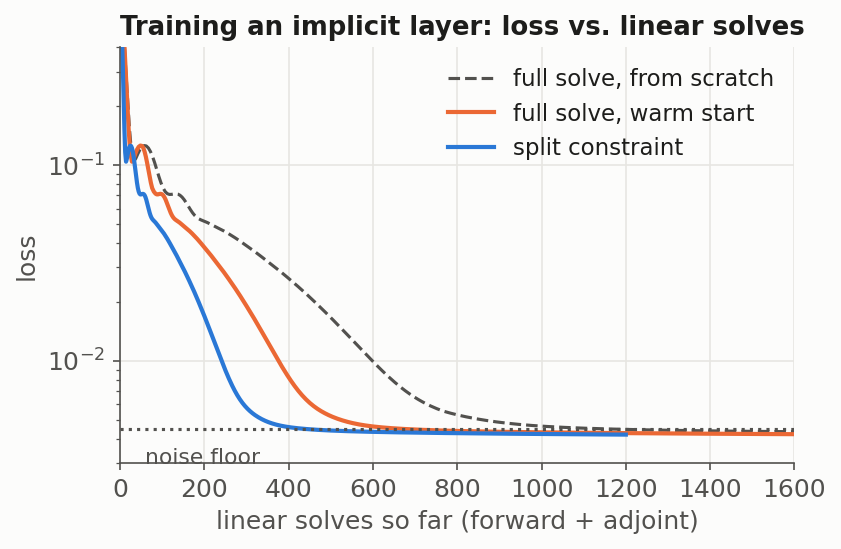

In [9]:
fig, ax = plt.subplots(figsize=(5.8, 3.6))
styles = {"full solve, from scratch": dict(color=INK2, ls="--", lw=1.5),
          "full solve, warm start": dict(color=ORANGE),
          "split constraint": dict(color=BLUE)}
for name, (hist, count) in runs.items():
    ax.semilogy(count, hist, label=name, **styles[name])
ax.set_xlim(0, 1600)
ax.axhline(noise_floor, color=INK2, ls=":", lw=1.5)
ax.text(60, noise_floor * 0.8, "noise floor", color=INK2, fontsize=10.5, ha="left", va="top")
ax.set(xlabel="linear solves so far (forward + adjoint)", ylabel="loss", ylim=(3e-3, 0.4),
       title="Training an implicit layer: loss vs. linear solves")
ax.legend(loc="upper right")

Each run gets the loss below 0.005 after 170 steps, and their loss curves agree to within a few times $10^{-4}$ throughout. So a single Newton iteration per step is enough to keep the state up to date as the parameters change, and computing the adjoint at an inexact state doesn't slow training down here. The split version needs 2 linear solves per step (one forward, one adjoint), compared with about 3 for a warm-started full solve and about 5 for a full solve from scratch, which works out to roughly 1.5 and 2.5 times fewer linear solves to reach the same loss. (The paper only counts forward solves, since the adjoint solve is the same for every method. Counted that way, the split version uses about half as many as the warm-started full solve.)

The savings depend on how many iterations a full forward solve takes. Newton's method converges very quickly from a warm start, so here a full solve is only about two iterations. With a forward solver that needs more iterations per solve, the savings would be larger.

## 5. Recap

- **Gradient descent is forward Euler** applied to the gradient flow $\dot\theta = -\nabla\mathcal{L}$, and thus a learning rate that's too high is the same as a time step that's too big.
- The **implicit step** (backward Euler, or the proximal point method) has no step-size limit, but each step requires a full nonlinear solve.
- A **nonlinear splitting** writes the gradient in terms of an old point and a new point, and is only implicit where that's cheap. For a least-squares loss, taking the Jacobian at the old point and the residual at the new one (plus one Newton step) gives Levenberg–Marquardt, and the step size moves it smoothly between gradient descent and Gauss–Newton.
- On Part 2's network, the split step reaches the noise floor in a handful of steps over a wide range of step sizes, far beyond gradient descent's limit. Even counting the extra work per step it came out ahead of Adam here, but the cost of a step grows quickly with the size of the problem, so this doesn't scale to large networks as is.
- **Splitting the constraint** applies the same old/new idea to the forward problem: each optimization step takes one cheap split step for the state instead of solving the forward problem exactly, so the state and the parameters converge together. This pays off when the forward solve is itself an expensive iteration, as in transport problems or implicit layers. On a small implicit layer, one Newton iteration per training step trained just as well as solving the layer fully, with about 1.5 times fewer linear solves than a warm-started full solve.

**References**

- Tran, B. K., Southworth, B. S., Cavender, D. B., Olivier, S., Shah, S. A. and Buvoli, T. (2025). Nonlinear splitting for gradient-based unconstrained and adjoint optimization. https://doi.org/10.48550/arXiv.2508.20280
- Levenberg, K. (1944). A method for the solution of certain non-linear problems in least squares. *Quarterly of Applied Mathematics*, 2.
- Marquardt, D. W. (1963). An algorithm for least-squares estimation of nonlinear parameters. *Journal of the Society for Industrial and Applied Mathematics*, 11(2).
- Hagan, M. T. and Menhaj, M. B. (1994). Training feedforward networks with the Marquardt algorithm. *IEEE Transactions on Neural Networks*, 5(6).
- Rockafellar, R. T. (1976). Monotone operators and the proximal point algorithm. *SIAM Journal on Control and Optimization*, 14(5).
- Bai, S., Kolter, J. Z. and Koltun, V. (2019). Deep equilibrium models. *NeurIPS*.